In [1]:
# Write your imports here
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile

# Data Visualization and Exploratory Data Analysis Lab
## Visualizing and exploring data. The data mining process

In this lab, you'll get acquainted with the most streamed songs on Spotify in 2024. The dataset and its associated metadata can be found [here](https://www.kaggle.com/datasets/nelgiriyewithana/most-streamed-spotify-songs-2024). The version you'll need is provided in the `data/` folder.

You know the drill. Do what you can / want / need to answer the questions to the best of your ability. Answers do not need to be trivial, or even the same among different people.

### Problem 1. Read the dataset (1 point)
Read the file without unzipping it first. You can try a different character encoding, like `unicode_escape`. Don't worry too much about weird characters.

In [2]:
zf = zipfile.ZipFile("data/spotify_most_streamed_2024.zip") 

In [3]:
music_data = pd.read_csv(zf.open("Most Streamed Spotify Songs 2024.csv"), encoding = "unicode_escape")

In [4]:
music_data.shape

(4600, 29)

In [5]:
pd.set_option('display.max_columns', 29)
music_data

,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,TikTok Posts,TikTok Likes,TikTok Views,YouTube Playlist Reach,Apple Music Playlist Count,AirPlay Spins,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",92.0,"84,274,754","1,713,126","5,767,700","651,565,900","5,332,281,936","150,597,040",210.0,"40,975",684,62.0,"17,598,718",114.0,"18,004,655","22,931","4,818,457","2,669,262",NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",92.0,"116,347,040","3,486,739","674,700","35,223,547","208,339,025","156,380,351",188.0,"40,778",3,67.0,"10,422,430",111.0,"7,780,028","28,444","6,623,075","1,118,279",NaN,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",92.0,"122,599,116","2,228,730","3,025,400","275,154,237","3,369,120,610","373,784,955",190.0,"74,333",536,136.0,"36,321,847",172.0,"5,022,621","5,639","7,208,651","5,285,340",NaN,0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",85.0,"1,096,100,899","10,629,796","7,189,811","1,078,757,968","14,603,725,994","3,351,188,582",394.0,"1,474,799","2,182",264.0,"24,684,248",210.0,"190,260,277","203,384",NaN,"11,822,942",NaN,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",88.0,"77,373,957","3,670,188","16,400",NaN,NaN,"112,763,851",182.0,"12,185",1,82.0,"17,660,624",105.0,"4,493,884","7,006","207,179","457,017",NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,For the Last Time,For the Last Time,$uicideboy$,9/5/2017,QM8DG1703420,"4,585",19.4,"305,049,963","65,770","5,103,054",71.0,"149,247,747","1,397,590","48,370","20,202,000","143,934,379","53,016",3.0,6,NaN,2.0,"14,217",NaN,"20,104,066","13,184","50,633,006","656,337",NaN,1
4596,Dil Meri Na Sune,"Dil Meri Na Sune (From ""Genius"")",Atif Aslam,7/27/2018,INT101800122,"4,575",19.4,"52,282,360","4,602","1,449,767",56.0,"943,920,245","5,347,766",NaN,"1,721","19,935","24,973,048",1.0,412,NaN,1.0,927,NaN,NaN,NaN,NaN,"193,590",NaN,0
4597,Grace (feat. 42 Dugg),My Turn,Lil Baby,2/28/2020,USUG12000043,"4,571",19.4,"189,972,685","72,066","6,704,802",65.0,"201,027,333","1,081,402","7,596","5,288,677","36,849,005","29,253,152",19.0,204,NaN,1.0,74,6.0,"84,426,740","28,999",NaN,"1,135,998",NaN,1
4598,Nashe Si Chadh Gayi,November Top 10 Songs,Arijit Singh,11/8/2016,INY091600067,"4,591",19.4,"145,467,020","14,037","7,387,064",66.0,"1,118,595,159","3,868,828","11,433","2,534,831","37,757,301","25,150,516",1.0,"1,200",NaN,NaN,NaN,7.0,"6,817,840",NaN,NaN,"448,292",NaN,0


Obviously, there are problems with the reading of some values such as the artist of observation with index 4599. Let's see what encoding is used.

In [6]:
import chardet

with zf.open("Most Streamed Spotify Songs 2024.csv") as f:
    raw = f.read(50000)  # read part of the file
    print(chardet.detect(raw))


{'encoding': 'ISO-8859-1', 'confidence': 0.73, 'language': ''}


In [7]:
# I tried many things but this is the one that worked
import zipfile
import pandas as pd

# Most frequent encodings for csv files
encodings_to_try = ["utf-8", "latin1", "cp1252", "ISO-8859-1"]

zf = zipfile.ZipFile("data/spotify_most_streamed_2024.zip")
file_name = "Most Streamed Spotify Songs 2024.csv"

for enc in encodings_to_try:
    try:
        music_data = pd.read_csv(zf.open(file_name), encoding=enc)
        print(f"✅ Successfully read with ='{enc}'")
        break
    except Exception as e:
        print(f"❌ Problem with encoding='{enc}': {e}")

❌ Problem with encoding='utf-8': 'utf-8' codec can't decode byte 0xfd in position 2679: invalid start byte
✅ Successfully read with ='latin1'


In [8]:
zf = zipfile.ZipFile("data/spotify_most_streamed_2024.zip")
file_name = "Most Streamed Spotify Songs 2024.csv"

with zf.open(file_name) as f:
    raw_bytes = f.read()

for enc in ["utf-8", "latin1", "cp1252", "ISO-8859-1"]:
    try:
        text = raw_bytes.decode(enc)
        print(f"✅ Successful with {enc}")
        print(text[:300])  
    except Exception as e:
        print(f"❌ {enc}: {e}")

from io import StringIO
music_data = pd.read_csv(StringIO(text))

❌ utf-8: 'utf-8' codec can't decode byte 0xfd in position 2679: invalid start byte
✅ Successful with latin1
Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,TikTok Posts,TikTok Likes,TikTok Views,YouTube Playlist Reach,Apple Music Playlist Count,AirPlay Spins,SiriusXM Spins,Deeze
✅ Successful with cp1252
Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,TikTok Posts,TikTok Likes,TikTok Views,YouTube Playlist Reach,Apple Music Playlist Count,AirPlay Spins,SiriusXM Spins,Deeze
✅ Successful with ISO-8859-1
Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,TikTok Posts,TikTok Likes,TikTok Views,YouTube Playlist Rea

In [9]:
music_data

,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,TikTok Posts,TikTok Likes,TikTok Views,YouTube Playlist Reach,Apple Music Playlist Count,AirPlay Spins,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",92.0,"84,274,754","1,713,126","5,767,700","651,565,900","5,332,281,936","150,597,040",210.0,"40,975",684,62.0,"17,598,718",114.0,"18,004,655","22,931","4,818,457","2,669,262",NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",92.0,"116,347,040","3,486,739","674,700","35,223,547","208,339,025","156,380,351",188.0,"40,778",3,67.0,"10,422,430",111.0,"7,780,028","28,444","6,623,075","1,118,279",NaN,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",92.0,"122,599,116","2,228,730","3,025,400","275,154,237","3,369,120,610","373,784,955",190.0,"74,333",536,136.0,"36,321,847",172.0,"5,022,621","5,639","7,208,651","5,285,340",NaN,0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",85.0,"1,096,100,899","10,629,796","7,189,811","1,078,757,968","14,603,725,994","3,351,188,582",394.0,"1,474,799","2,182",264.0,"24,684,248",210.0,"190,260,277","203,384",NaN,"11,822,942",NaN,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",88.0,"77,373,957","3,670,188","16,400",NaN,NaN,"112,763,851",182.0,"12,185",1,82.0,"17,660,624",105.0,"4,493,884","7,006","207,179","457,017",NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,For the Last Time,For the Last Time,$uicideboy$,9/5/2017,QM8DG1703420,"4,585",19.4,"305,049,963","65,770","5,103,054",71.0,"149,247,747","1,397,590","48,370","20,202,000","143,934,379","53,016",3.0,6,NaN,2.0,"14,217",NaN,"20,104,066","13,184","50,633,006","656,337",NaN,1
4596,Dil Meri Na Sune,"Dil Meri Na Sune (From ""Genius"")",Atif Aslam,7/27/2018,INT101800122,"4,575",19.4,"52,282,360","4,602","1,449,767",56.0,"943,920,245","5,347,766",NaN,"1,721","19,935","24,973,048",1.0,412,NaN,1.0,927,NaN,NaN,NaN,NaN,"193,590",NaN,0
4597,Grace (feat. 42 Dugg),My Turn,Lil Baby,2/28/2020,USUG12000043,"4,571",19.4,"189,972,685","72,066","6,704,802",65.0,"201,027,333","1,081,402","7,596","5,288,677","36,849,005","29,253,152",19.0,204,NaN,1.0,74,6.0,"84,426,740","28,999",NaN,"1,135,998",NaN,1
4598,Nashe Si Chadh Gayi,November Top 10 Songs,Arijit Singh,11/8/2016,INY091600067,"4,591",19.4,"145,467,020","14,037","7,387,064",66.0,"1,118,595,159","3,868,828","11,433","2,534,831","37,757,301","25,150,516",1.0,"1,200",NaN,NaN,NaN,7.0,"6,817,840",NaN,NaN,"448,292",NaN,0


In [10]:
def fix_encoding(x):
    if isinstance(x, str):
        try:
            return x.encode("latin1").decode("utf-8")
        except Exception:
            return x
    return x

music_data = music_data.applymap(fix_encoding)


C:\Users\aneli\AppData\Local\Temp\ipykernel_1584\1661152744.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  music_data = music_data.applymap(fix_encoding)


### Problem 2. Perform some cleaning (1 point)
Ensure all data has been read correctly; check the data types. Give the columns better names (e.g. `all_time_rank`, `track_score`, etc.). To do so, try to use `apply()` instead of a manual mapping between old and new name. Get rid of any unnecessary ones.

In [11]:
music_data = music_data.rename(columns = lambda col: col.replace(" ", "_").lower())

In [12]:
music_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   track                       4600 non-null   object 
 1   album_name                  4600 non-null   object 
 2   artist                      4595 non-null   object 
 3   release_date                4600 non-null   object 
 4   isrc                        4600 non-null   object 
 5   all_time_rank               4600 non-null   object 
 6   track_score                 4600 non-null   float64
 7   spotify_streams             4487 non-null   object 
 8   spotify_playlist_count      4530 non-null   object 
 9   spotify_playlist_reach      4528 non-null   object 
 10  spotify_popularity          3796 non-null   float64
 11  youtube_views               4292 non-null   object 
 12  youtube_likes               4285 non-null   object 
 13  tiktok_posts                3427 

There are 5 artists who are missing so I will fill them in the next problem.

In [13]:
# A simple check to see if isrc has something in common with the artist. 
music_data[music_data.artist == "Dua Lipa"]["isrc"]

46      GBAHT2301246
84      USAT22305457
105     GBAHT2301078
148     GBAHT1901121
183     GBAHT2000942
224     GBAHT2400114
498     GBAHT1901303
703     TRAA31800147
845     GBAHT1901299
1118    GBAHT1901298
1285    GBAHT1901302
1566    GBAHT1600310
1660    USAT22305730
2063    GBAHT2001117
3285    GBAHT2400111
3555    GBAHT2000834
3684    GBAHT1600301
Name: isrc, dtype: object

In [14]:
music_data[music_data.isrc.str.contains("USAT")].artist

5                      Jack Harlow
38                           Gunna
84                        Dua Lipa
108                    Roddy Ricch
122                    Jack Harlow
                   ...            
4538                  Hugh Jackman
4549                         Bazzi
4555                       Faouzia
4574    YoungBoy Never Broke Again
4591                  Jaymes Young
Name: artist, Length: 226, dtype: object

ISRC has nothing in common with the artist.

First, I will remove all the columns which I do not need for the rest of the homework.
- ISRC does not give me any useful information for the analysis.
- 'siriusxm_spins', 'pandora_streams', 'pandora_track_stations', 'soundcloud_streams', 'shazam_counts', 'tidal_popularity' are not needed in any of the tasks.
- Furthermore 'tidal_popularity' has only NaN values which is absolutely not useful for the analysis.
- 'soundcloud_streams' have only 1267 not-null values which means that approx. 1/4 of all records have values in this variable. And that is not enough.
   

In [15]:
music_data = music_data.drop(columns = {"isrc", "siriusxm_spins", "pandora_streams", "pandora_track_stations", "soundcloud_streams", "shazam_counts", "tidal_popularity"})

### Problem 3. Most productive artists (1 point)
Who are the five artists with the most songs in the dataset?

Who are the five "clean-mouthed" artists (i.e., with no explicit songs)? **Note:** We're not going into details but we can start a discussion about whether a song needs swearing to be popular.

First, let's check who are the missing artists.

In [16]:
music_data[music_data.artist.isna()]

,track,album_name,artist,release_date,all_time_rank,track_score,spotify_streams,spotify_playlist_count,spotify_playlist_reach,spotify_popularity,youtube_views,youtube_likes,tiktok_posts,tiktok_likes,tiktok_views,youtube_playlist_reach,apple_music_playlist_count,airplay_spins,deezer_playlist_count,deezer_playlist_reach,amazon_playlist_count,explicit_track
311,Cool,JnD Mix,NaN,5/25/2024,311,86.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
480,I Wanna Party,I Wanna Party - Single,NaN,5/31/2024,482,70.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1345,Marlboro Remix,Marlboro Remix - Single,NaN,6/7/2024,"1,343",40.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1561,Melting,Melting - Single,NaN,6/10/2024,"1,553",37.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3402,La ��ltima Vez (Yo Te Per,La ��ltima Vez (Yo Te Perd��),NaN,5/2/2024,"3,381",23.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [17]:
# Check if there are other tracks in the same album 
def check_tracks_in_album(album):
    print(f"Album name: {album}")
    artist = music_data[music_data["album_name"] == album]["artist"].unique()
    print(f"Artist: {artist}")
    print("\n" + "-"*50 + "\n")


In [18]:
for album in music_data[music_data.artist.isna()]["album_name"]:
    check_tracks_in_album(album)


Album name: JnD Mix
Artist: [nan]

--------------------------------------------------

Album name: I Wanna Party - Single
Artist: [nan]

--------------------------------------------------

Album name: Marlboro Remix - Single
Artist: [nan]

--------------------------------------------------

Album name: Melting - Single
Artist: [nan]

--------------------------------------------------

Album name: La ��ltima Vez (Yo Te Perd��) 
Artist: [nan]

--------------------------------------------------



I will perform an online research to see the artists.
- For JnD Mix I found that JnD is the artist: [link to Spotify](https://open.spotify.com/artist/1bURTsZa0l5C5nqZ9ygnUV)
- For "I Wanna Party - Single" I found various artists so I will replace the NaN value with "Unknown".
- The same for "Marlboro Remix - Single" and "Melting - Single".
- The last album will be renamed so that its whole name can be seen because the strange characters prevent good reading. I copied this strange name in and pasted it in Google and found the album behind this name is: La Última Vez and its artist is Anuel AA featuring Bad Bunny.

In [19]:
music_data.loc[music_data["album_name"] == "JnD Mix", "artist"] = "JnD"

In [20]:
# Rename the album with strange characters
music_data.loc[
    music_data["album_name"].str.contains("ltima Vez", na=False),
    "album_name"
] = "La Última Vez"

# Rename the track so that it does not have strange symbols and add Bad Bunny as as a featuring artist
music_data.loc[
    music_data.track.str.contains("ltima Vez", na=False),
    "track"
] = "La Última Vez (Yo Te Perdí) (ft. Bad Bunny)"

# Add Anuel AA as an artist
music_data.loc[music_data["album_name"] == "La Última Vez", "artist"] = "Anuel AA"

In [21]:
music_data.loc[music_data["album_name"] == "La Última Vez"]

,track,album_name,artist,release_date,all_time_rank,track_score,spotify_streams,spotify_playlist_count,spotify_playlist_reach,spotify_popularity,youtube_views,youtube_likes,tiktok_posts,tiktok_likes,tiktok_views,youtube_playlist_reach,apple_music_playlist_count,airplay_spins,deezer_playlist_count,deezer_playlist_reach,amazon_playlist_count,explicit_track
3402,La Última Vez (Yo Te Perdí) (ft. Bad Bunny),La Última Vez,Anuel AA,5/2/2024,"3,381",23.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [22]:
# Interestingly, "string" is the new StringDtype format in pandas; it handles missing values better than the old object string type
music_data["artist"] = music_data["artist"].astype("string").fillna("Unknown")

Now the 'artist' variable is cleaned and ready to be deeply explored.

In [23]:
# Top Five artists with the most songs in the dataset
music_data.artist.value_counts(dropna = False).head(5)

artist
Taylor Swift    63
Drake           63
Bad Bunny       60
KAROL G         32
The Weeknd      31
Name: count, dtype: Int64

Five clean-mouthed artists

In [24]:
music_data["explicit_track"].value_counts(dropna = False)

explicit_track
0    2949
1    1651
Name: count, dtype: int64

In [25]:
music_data.artist

0        Tommy Richman
1       Kendrick Lamar
2              Artemas
3          Miley Cyrus
4               Eminem
             ...      
4595       $uicideboy$
4596        Atif Aslam
4597          Lil Baby
4598      Arijit Singh
4599             Arc��
Name: artist, Length: 4600, dtype: string

In [26]:
music_data[music_data.artist == "Miley Cyrus"]["explicit_track"]

3       0
226     0
1203    1
1326    0
1334    0
1630    0
1701    0
2015    0
2103    0
2716    0
3758    0
3763    0
4052    0
Name: explicit_track, dtype: int64

In [27]:
clean_mouthed_artist = []
for artist in music_data.artist.unique():
    if music_data[music_data.artist == artist]["explicit_track"].sum() == 0:
        clean_mouthed_artist.append(artist)
print(f"Count of clean-mouthed artists: {len(clean_mouthed_artist)}")

Count of clean-mouthed artists: 1323


### Problem 4. Most streamed artists (1 point)
And who are the top five most streamed (as measured by Spotify streams) artists?

In [28]:
# Check for the type of the var 'spotify_streams'
music_data["spotify_streams"].dtype

dtype('O')

In [29]:
# Check for NaN values
music_data["spotify_streams"].isna().value_counts()

spotify_streams
False    4487
True      113
Name: count, dtype: int64

There are 113 tracks which do not have values for spotify_streams.

In [30]:
music_data["spotify_streams"].value_counts()

spotify_streams
1,655,575,417    4
1,642,258,500    3
720,822,868      2
3,107,100,349    2
1,065,399,331    2
                ..
122,999,909      1
23,388,367       1
583,209,382      1
315,697,428      1
1,088,273,121    1
Name: count, Length: 4425, dtype: int64

In [31]:
music_data["spotify_streams"].dtype.name

'object'

In [32]:
# The feature is in type string so I will remove the commas and convert it ro float
music_data["spotify_streams"] = music_data["spotify_streams"].str.replace(",", "")

In [33]:
music_data["spotify_streams"] = music_data["spotify_streams"].astype("Int64")

In [34]:
for artist in music_data[music_data["spotify_streams"].isna()]["artist"].unique():
    
    # Take only non-NaN streams for the artist
    artist_streams = music_data[(music_data.artist == artist) & (music_data.spotify_streams.notna())]["spotify_streams"]
    
    # Calculate average or fallback to 0 if all are NaN
    if not artist_streams.empty:
        replacement_value = round(artist_streams.mean())
    else:
        replacement_value = 0
    
    # Replace NaN with average or 0
    music_data.loc[
        (music_data.artist == artist) & (music_data.spotify_streams.isna()), 
        "spotify_streams"
    ] = replacement_value


In [35]:
# Now I will check the top five artists with the most Spotify Streams
most_streamed_artists = music_data.pivot_table(index = "artist", values = "spotify_streams", aggfunc = "sum")
most_streamed_artists = most_streamed_artists.sort_values(by="spotify_streams", ascending=False)
most_streamed_artists.head(5)

,spotify_streams
artist,
The Weeknd,38180158287
Bad Bunny,37054834425
Drake,35526063344
Taylor Swift,34470771165
Post Malone,26137472958


### Problem 5. Songs by year and month (1 point)
How many songs have been released each year? Present an appropriate plot. Can you explain the behavior of the plot for 2024?

How about months? Is / Are there (a) popular month(s) to release music?

In [36]:
# Convert the release data to datetime
music_data["release_date"] = pd.to_datetime(music_data["release_date"])
# Create a new feature - year
music_data["year"] = music_data["release_date"].dt.year
# Group by year to see the count of tracks for each year
songs_per_year = music_data.groupby("year")["track"].count().reset_index()
songs_per_year


,year,track
0,1987,1
1,1991,1
2,1994,1
3,1998,1
4,1999,1
5,2000,2
6,2001,1
7,2002,5
8,2003,3
9,2004,5


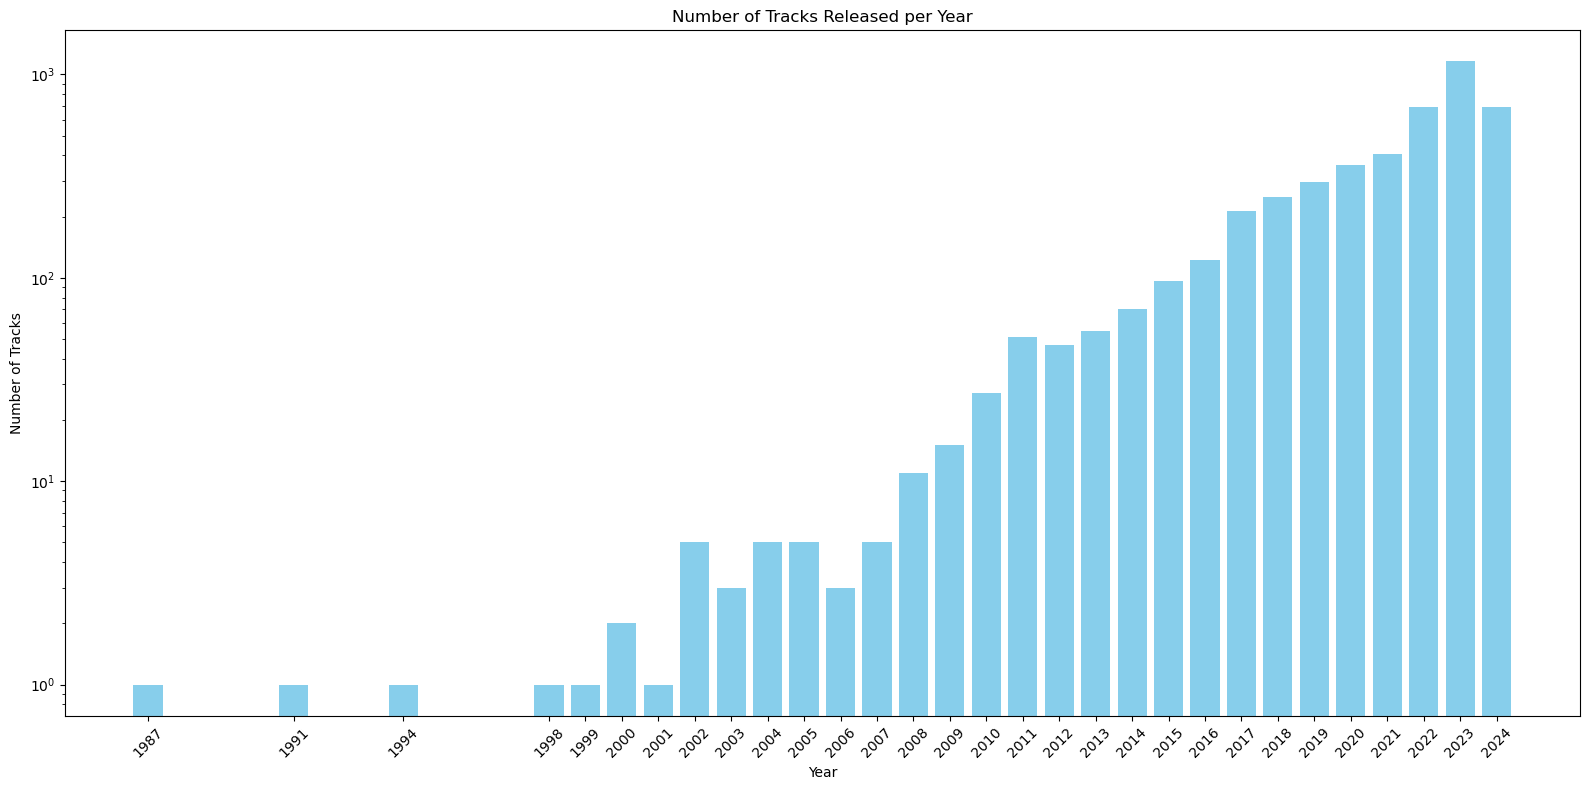

In [37]:
plt.figure(figsize = (16, 8))
plt.bar(songs_per_year["year"], songs_per_year["track"], color='skyblue')
plt.xlabel("Year")
plt.ylabel("Number of Tracks")
plt.title("Number of Tracks Released per Year")
plt.yscale('log')  # otherwise chart will look empty
plt.xticks(songs_per_year["year"], rotation=45)
plt.tight_layout()
plt.show()


2023 is the peak of song releasing but there is a huge decrease in 2024. 

In [38]:
# Months

# Create a new feature - month to store the months
music_data["month"] = music_data["release_date"].dt.month
# Group by year to see the count of tracks for each month
songs_per_month = music_data.groupby("month")["track"].count().reset_index()
songs_per_month


,month,track
0,1,503
1,2,371
2,3,430
3,4,420
4,5,511
5,6,395
6,7,321
7,8,315
8,9,328
9,10,384


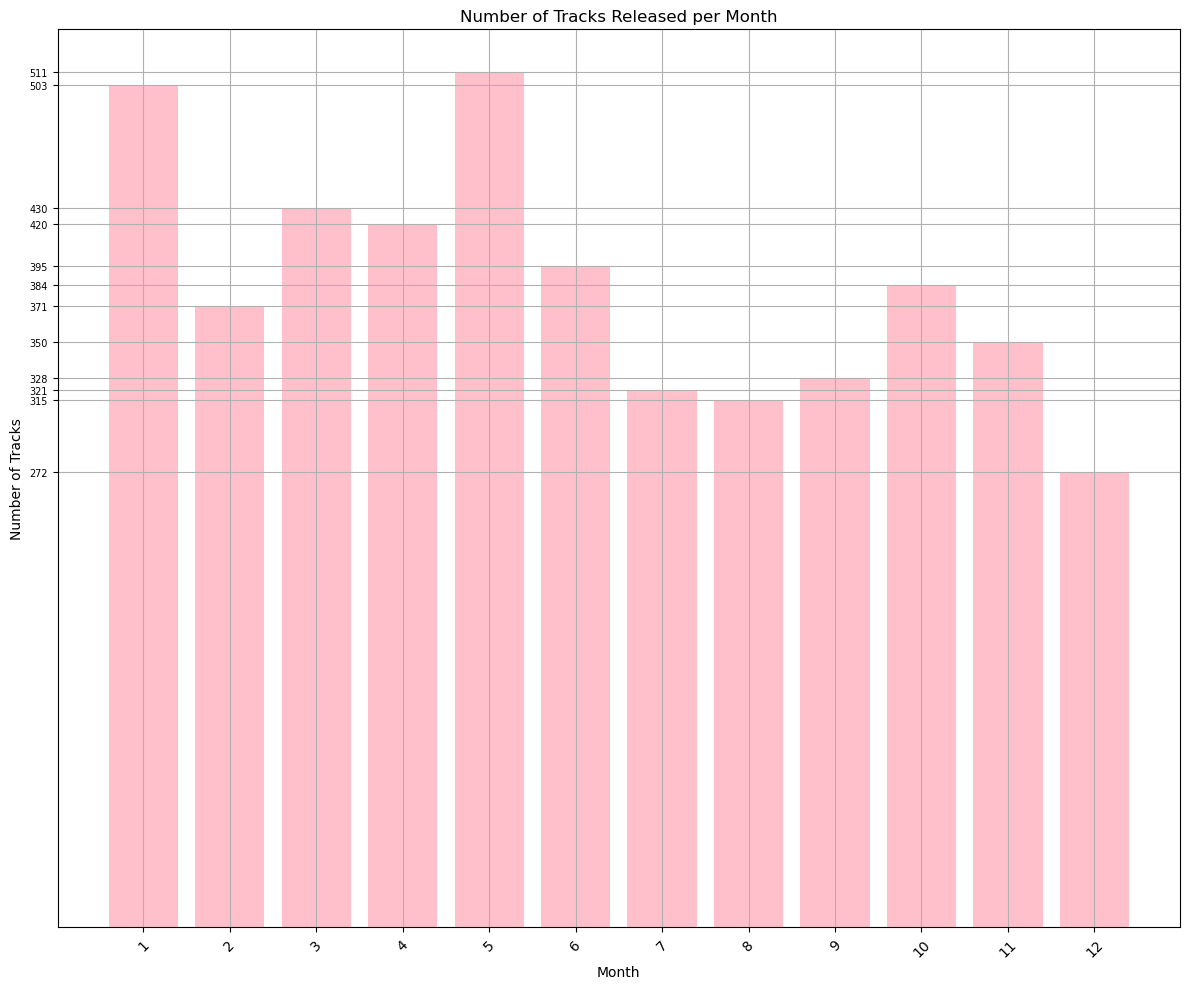

In [39]:
plt.figure(figsize=(12, 10))
plt.bar(songs_per_month["month"], songs_per_month["track"], color='pink')
plt.xlabel("Month")
plt.ylabel("Number of Tracks")
plt.title("Number of Tracks Released per Month")
plt.xticks(songs_per_month["month"], rotation = 45)
plt.yticks(songs_per_month["track"], fontsize = 7)
plt.ticklabel_format(style='plain', axis='y') 
plt.tight_layout()
plt.grid(True)
plt.show()

### Problem 6. Playlists (2 points)
Is there any connection (correlation) between users adding a song to playlists in one service, or another? Only Spotify, Apple, Deezer, and Amazon offer the ability to add a song to a playlist. Find a way to plot all these relationships at the same time, and analyze them. Experiment with different types of correlations.

### Problem 7. YouTube views and likes (1 point)
What is the relationship between YouTube views and likes? Present an appropriate plot. 

What is the mean YouTube views-to-likes ratio? What is its distribution? Find a way to plot it and describe it.

In [40]:
music_data['youtube_views'].isna().value_counts()

youtube_views
False    4292
True      308
Name: count, dtype: int64

In [41]:
music_data['youtube_likes'].isna().value_counts()

youtube_likes
False    4285
True      315
Name: count, dtype: int64

There are NaN values for these two features so I will proceed the way I did in problem 4.

In [42]:
# The feature is in type string so I will remove the commas and convert it ro float
music_data["youtube_views"] = music_data["youtube_views"].str.replace(",", "")
# Convert to Int64 which accepts NaN
music_data["youtube_views"] = music_data["youtube_views"].astype("Int64")

for artist in music_data[music_data["youtube_views"].isna()]["artist"].unique():
    
    # Take only non-NaN streams for the artist
    artist_youtube_views = music_data[(music_data.artist == artist) & (music_data.youtube_views.notna())]["youtube_views"]
    
    # Calculate average or fallback to 0 if all are NaN
    if not artist_youtube_views.empty:
        replacement_value = round(artist_youtube_views.mean())
    else:
        replacement_value = 0
    
    # Replace NaN with average or 0
    music_data.loc[
        (music_data.artist == artist) & (music_data.youtube_views.isna()), 
        "artist_youtube_views"
    ] = replacement_value


In [43]:
# I do the same for youtube_likes

# The feature is in type string so I will remove the commas and convert it ro float
music_data["youtube_likes"] = music_data["youtube_likes"].str.replace(",", "")
# Convert to Int64 which accepts NaN
music_data["youtube_likes"] = music_data["youtube_likes"].astype("Int64")

for artist in music_data[music_data["youtube_likes"].isna()]["artist"].unique():
    
    # Take only non-NaN streams for the artist
    artist_youtube_likes = music_data[(music_data.artist == artist) & (music_data.youtube_likes.notna())]["youtube_likes"]
    
    # Calculate average or fallback to 0 if all are NaN
    if not artist_youtube_likes.empty:
        replacement_value = round(artist_youtube_likes.mean())
    else:
        replacement_value = 0
    
    # Replace NaN with average or 0
    music_data.loc[
        (music_data.artist == artist) & (music_data.youtube_likes.isna()), 
        "artist_youtube_likes"
    ] = replacement_value


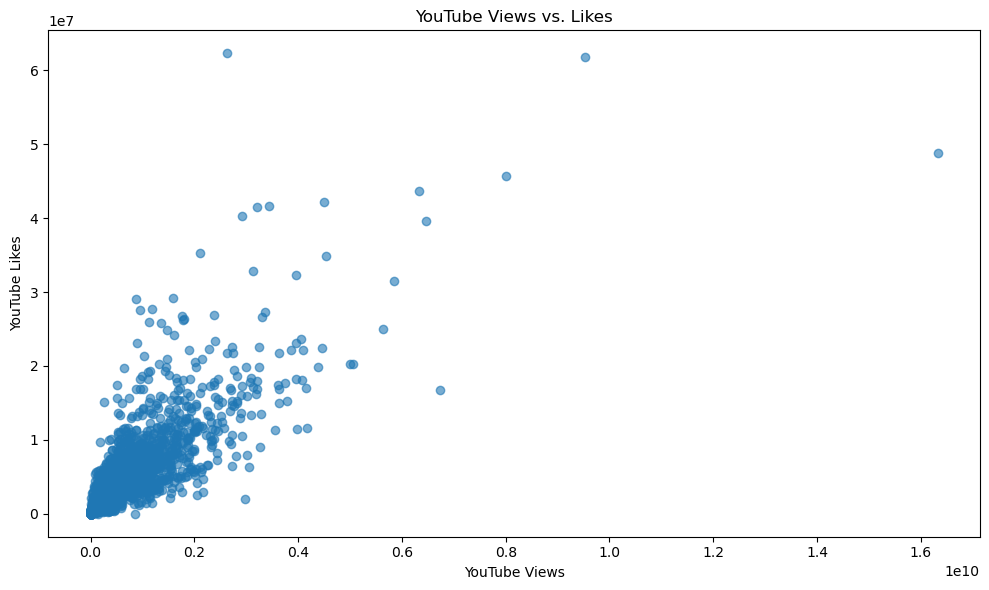

In [44]:
# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(music_data['youtube_views'], music_data['youtube_likes'], alpha=0.6)
plt.title('YouTube Views vs. Likes')
plt.xlabel('YouTube Views')
plt.ylabel('YouTube Likes')
plt.tight_layout()
plt.show()

The plot shows a positive correlation between views and likes. This means that songs with more views tend to receive more likes. However, the relationship is not perfectly linear, suggesting other factors influence the number of likes.

In [45]:
# Views-to-likes ratio
music_data['views_to_likes_ratio'] = music_data['youtube_views'] / music_data['youtube_likes']

# Mean ratio
mean_ratio = music_data['views_to_likes_ratio'].mean()
print(f"Mean Views-to-Likes Ratio: {mean_ratio:.2f}")


Mean Views-to-Likes Ratio: 169.12


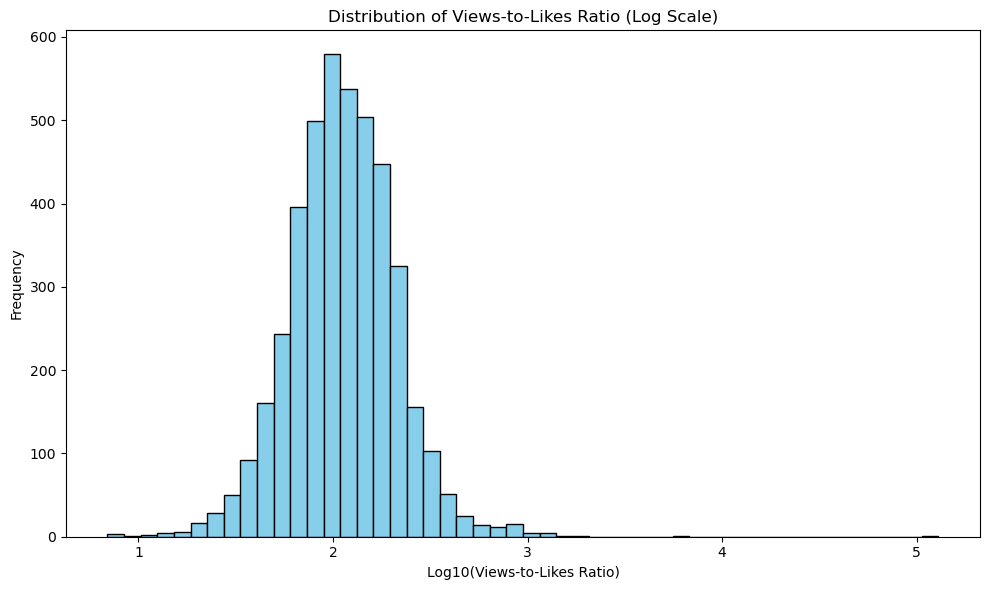

In [46]:
# Drop NaN or inf ratios
ratios = music_data['views_to_likes_ratio'].replace([np.inf, -np.inf], np.nan).dropna()

plt.figure(figsize=(10, 6))
plt.hist(np.log10(ratios), bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Views-to-Likes Ratio (Log Scale)')
plt.xlabel('Log10(Views-to-Likes Ratio)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


The distribution looks like Gaussian distribution.

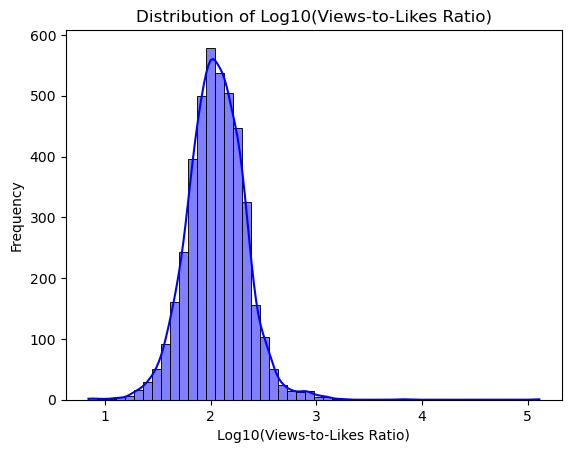

In [47]:
# Fancier histogram
import seaborn as sns

sns.histplot(np.log10(ratios), bins=50, kde=True, color="blue")
plt.title("Distribution of Log10(Views-to-Likes Ratio)")
plt.xlabel("Log10(Views-to-Likes Ratio)")
plt.ylabel("Frequency")
plt.show()


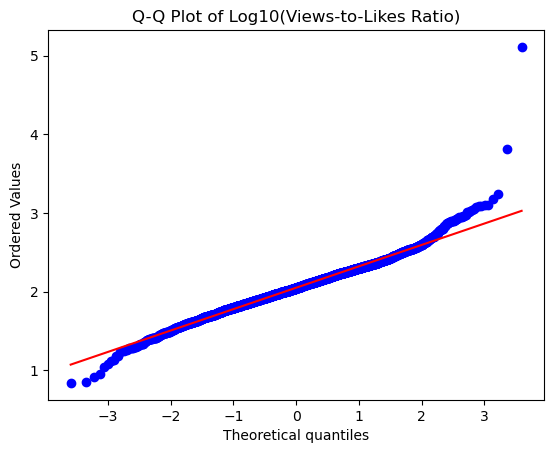

In [48]:
import scipy.stats as stats

""" 
I found that diagram.
Its purpose is to check if the ratio has the perfect normal distribution. 
If the blue line falls exactly on the red line, then this is the perfect Gaussian distribution. 
However, small deviations mean that the distribution is approximately normal.
"""

stats.probplot(np.log10(ratios), dist="norm", plot=plt)
plt.title("Q-Q Plot of Log10(Views-to-Likes Ratio)")
plt.show()


### Problem 8. TikTok stuff (2 points)
The most popular songs on TikTok released every year show... interesting behavior. Which years peaked the most TikTok views? Show an appropriate chart. Can you explain this behavior? For a bit of context, TikTok was created in 2016.

Now, how much popular is the most popular song for each release year, than the mean popularity? Analyze the results.

In both parts, it would be helpful to see the actual songs.

In [49]:
# I do this because TikTok did not exist before 2016.
music_data.loc[music_data["year"] < 2016, ["tiktok_views", "tiktok_likes", "tiktok_posts"]] = np.nan
music_data[music_data.year < 2016][["tiktok_views", "tiktok_likes", "tiktok_posts"]]

,tiktok_views,tiktok_likes,tiktok_posts
27,NaN,NaN,NaN
250,NaN,NaN,NaN
253,NaN,NaN,NaN
263,NaN,NaN,NaN
375,NaN,NaN,NaN
...,...,...,...
4547,NaN,NaN,NaN
4548,NaN,NaN,NaN
4557,NaN,NaN,NaN
4575,NaN,NaN,NaN


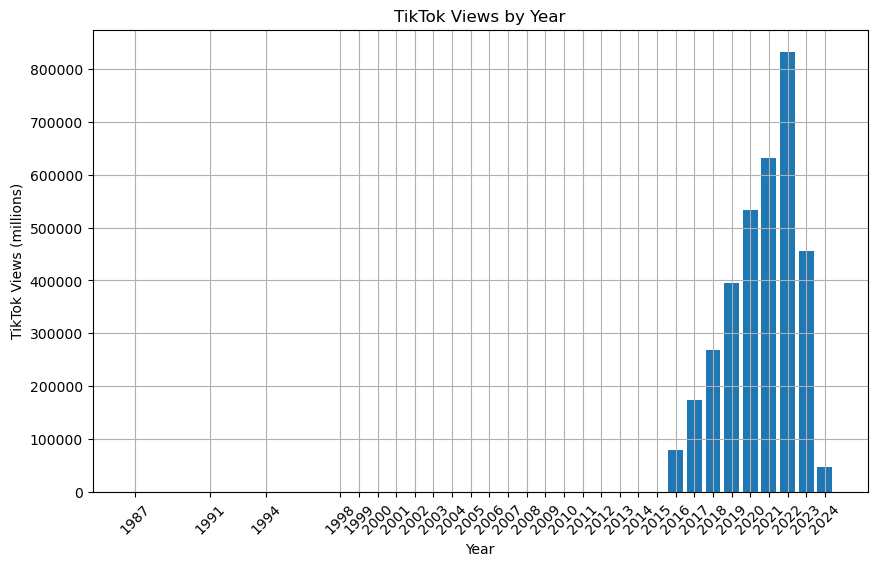

In [50]:

music_data["tiktok_views"] = music_data["tiktok_views"].str.replace(",", "")
music_data["tiktok_views"] = music_data["tiktok_views"].astype("Int64")
tiktok_group = music_data.groupby("year")["tiktok_views"].sum().reset_index()

tiktok_group["tiktok_views_m"] = tiktok_group["tiktok_views"] / 1_000_000

plt.figure(figsize=(10,6))
plt.bar(tiktok_group["year"], tiktok_group["tiktok_views_m"])

plt.xlabel("Year")
plt.ylabel("TikTok Views (millions)")
plt.title("TikTok Views by Year")
plt.xticks(ticks=tiktok_group["year"], rotation=45)
plt.grid(True)
plt.show()

Years from 2019 - 2022 are the top three years with most TikTok views exactly in the period when COVID-19 was in its peak. This may be integrated into my project some day.

In [51]:
# Convert them to int
music_data["tiktok_posts"] = music_data["tiktok_posts"].str.replace(",", "")
music_data["tiktok_posts"] = music_data["tiktok_posts"].astype("Int64")

music_data["tiktok_likes"] = music_data["tiktok_likes"].str.replace(",", "")
music_data["tiktok_likes"] = music_data["tiktok_likes"].astype("Int64")

In [52]:
music_data["total_tiktok_popularity"] = music_data["tiktok_likes"] + music_data["tiktok_posts"] + music_data["tiktok_views"]

In [53]:
# Sort the songs descendingly
top_songs = music_data.sort_values(by="total_tiktok_popularity", ascending=False)

top_songs.head(10)[["track", "artist", "total_tiktok_popularity"]]

,track,artist,total_tiktok_popularity
474,Oh No,Kreepa,66066933005
1547,Funny Song,Cavendish Music,41834673100
3377,Spongebob,Dante9k,36973383449
113,Aesthetic,Tollan Kim,36343408259
1163,She Share Story,Shayne Orok,36057544021
3383,Pieces,Danilo Stankovic,30710129013
26,STAY (with Justin Bieber),The Kid LAROI,25966854331
255,love nwantiti (ah ah ah),CKay,25714624262
1255,Steven Universe,L.Dre,25627322507
25,Beat Automotivo Tan Tan Tan Viral,WZ Beat,24593094366


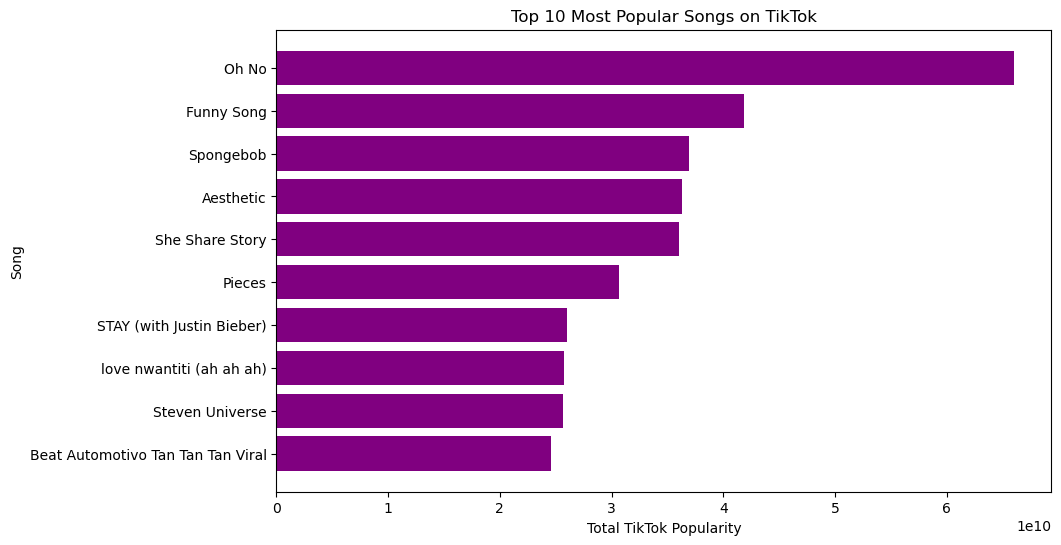

In [55]:
top10 = top_songs.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["track"], top10["total_tiktok_popularity"], color="purple")
plt.xlabel("Total TikTok Popularity")
plt.ylabel("Song")
plt.title("Top 10 Most Popular Songs on TikTok")
plt.gca().invert_yaxis() 
plt.show()

### * Problem 9. Explore (and clean) at will
There is a lot to look for here. For example, you can easily link a song to its genres, and lyrics. You may also try to link artists and albums to more info about them. Or you can compare and contrast a song's performance across different platforms, in a similar manner to what you already did above; maybe even assign a better song ranking system (across platforms with different popularity metrics, and different requirements) than the one provided in the dataset.